In [157]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

In [158]:
data = pd.read_csv('framingham.csv')

# EDA

In [159]:
data.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [160]:
data.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='str')

In [161]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [162]:
data.shape

(4238, 16)

In [163]:
data.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [164]:
data.male.value_counts()

male
0    2419
1    1819
Name: count, dtype: int64

In [165]:
data.age.unique()

array([39, 46, 48, 61, 43, 63, 45, 52, 50, 41, 38, 42, 44, 47, 60, 35, 36,
       59, 54, 37, 56, 53, 49, 65, 51, 62, 40, 67, 57, 66, 64, 55, 58, 34,
       68, 33, 70, 32, 69])

In [166]:
data.education.value_counts()

education
1.0    1720
2.0    1253
3.0     687
4.0     473
Name: count, dtype: int64

In [167]:
data.currentSmoker.value_counts()

currentSmoker
0    2144
1    2094
Name: count, dtype: int64

In [168]:
data.BPMeds.value_counts()

BPMeds
0.0    4061
1.0     124
Name: count, dtype: int64

In [169]:
data.prevalentStroke.value_counts()

prevalentStroke
0    4213
1      25
Name: count, dtype: int64

In [170]:
data.prevalentHyp.value_counts()

prevalentHyp
0    2922
1    1316
Name: count, dtype: int64

In [171]:
data.diabetes.value_counts()

diabetes
0    4129
1     109
Name: count, dtype: int64

In [172]:
data.TenYearCHD.value_counts()

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

# Missing Values

In [173]:
data.isna().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [174]:
data.education = data.education.fillna(data.education.mode()[0])

In [175]:
data.cigsPerDay = data.cigsPerDay.fillna(data.cigsPerDay.median())

In [176]:
data.BPMeds = data.BPMeds.fillna(data.BPMeds.mode()[0])

In [177]:
data.totChol = data.totChol.fillna(data.totChol.median())

In [178]:
data.BMI = data.BMI.fillna(data.BMI.median())

In [179]:
data.heartRate = data.heartRate.fillna(data.heartRate.mean())

In [180]:
data.glucose = data.glucose.fillna(data.glucose.median())

In [181]:
data.duplicated().sum()

np.int64(0)

# Selecting Input/Ouput

<Axes: >

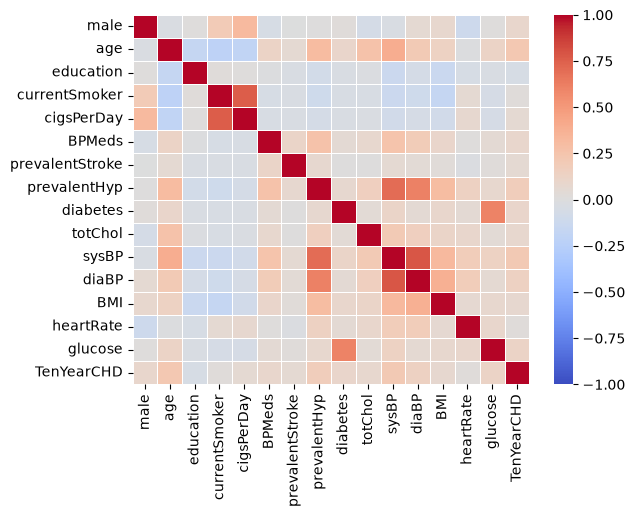

In [125]:
sns.heatmap(data.corr(),
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            vmin=-1, vmax=1)

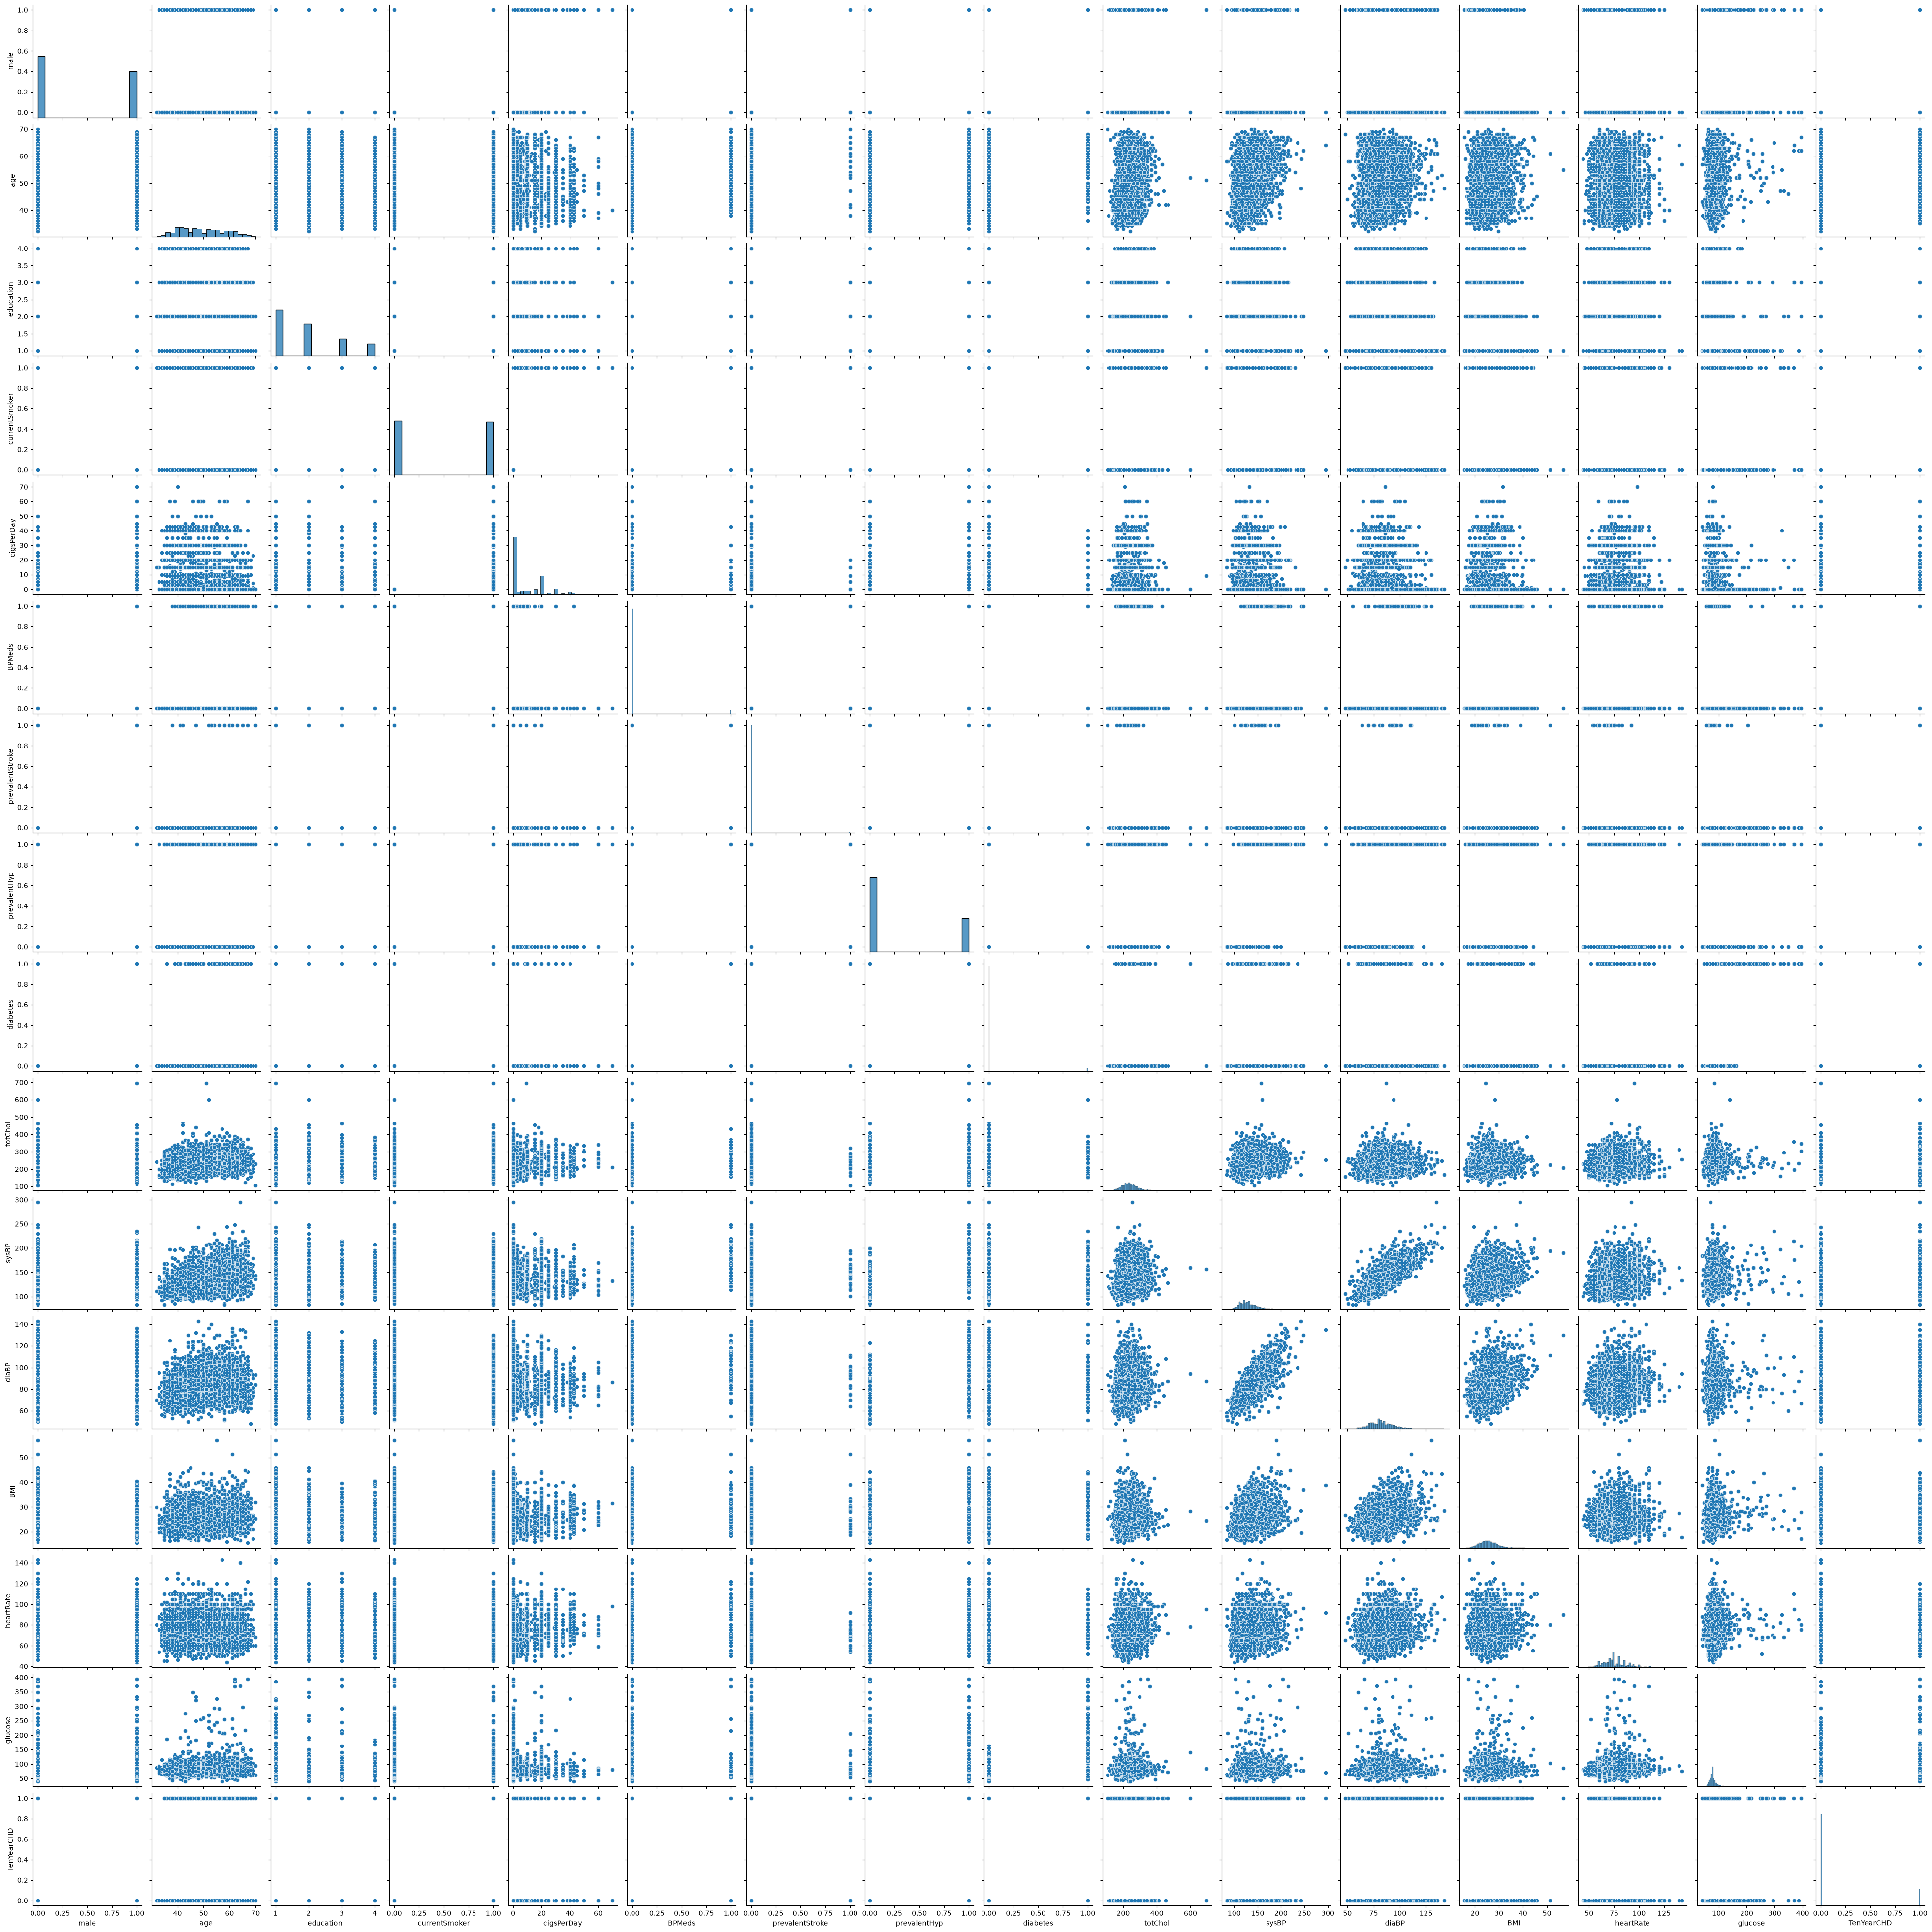

In [85]:
sns.pairplot(data)

In [182]:
data.corr()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
male,1.000000,-0.028979,0.013299,0.197596,0.315630,-0.051545,-0.004546,0.005313,0.015708,-0.069549,-0.035989,0.057933,0.081653,-0.116601,0.010073,0.088428
age,-0.028979,1.000000,-0.164809,-0.213748,-0.191847,0.120955,0.057655,0.307194,0.101258,0.260105,0.394302,0.206104,0.135174,-0.012819,0.117788,0.225256
education,0.013299,-0.164809,1.000000,0.019403,0.009905,-0.010149,-0.032881,-0.078807,-0.038147,-0.023423,-0.126197,-0.062732,-0.139458,-0.049604,-0.034641,-0.052812
currentSmoker,0.197596,-0.213748,0.019403,1.000000,0.760239,-0.048358,-0.032988,-0.103260,-0.044295,-0.046466,-0.130230,-0.107746,-0.167161,0.062348,-0.055177,0.019456
cigsPerDay,0.315630,-0.191847,0.009905,0.760239,1.000000,-0.044675,-0.032244,-0.065046,-0.036150,-0.026976,-0.088375,-0.056687,-0.092211,0.073866,-0.056863,0.058859
BPMeds,-0.051545,0.120955,-0.010149,-0.048358,-0.044675,1.000000,0.114609,0.258697,0.051394,0.078578,0.251503,0.192356,0.099584,0.015139,0.049124,0.086417
prevalentStroke,-0.004546,0.057655,-0.032881,-0.032988,-0.032244,0.114609,1.000000,0.074830,0.006949,0.000123,0.057009,0.045190,0.024265,-0.017676,0.018722,0.061810
prevalentHyp,0.005313,0.307194,-0.078807,-0.103260,-0.065046,0.258697,0.074830,1.000000,0.077808,0.163054,0.696755,0.615751,0.300510,0.147222,0.083571,0.177603
diabetes,0.015708,0.101258,-0.038147,-0.044295,-0.036150,0.051394,0.006949,0.077808,1.000000,0.040117,0.111283,0.050329,0.086025,0.048993,0.606493,0.097317
totChol,-0.069549,0.260105,-0.023423,-0.046466,-0.026976,0.078578,0.000123,0.163054,0.040117,1.000000,0.207522,0.163888,0.114811,0.090530,0.045559,0.081566


# Seperate Input/Output

In [183]:
X = data.drop(columns=['TenYearCHD'])
y= data.TenYearCHD

# Sepearate Train/Test Data

In [184]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling

In [186]:
y.value_counts()

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

In [187]:
# Balancing Data
sote = SMOTE(sampling_strategy= 'minority', random_state= 42)
X_train, y_train = sote.fit_resample(X_train, y_train)

In [203]:
continuous_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

In [188]:
# scaling data
scale = StandardScaler()
X_train[continuous_cols] = scale.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scale.transform(X_test[continuous_cols])

# Model Training

In [189]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

# Prediction

In [190]:
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

In [191]:
# prediction accuracy
accuracy_score(y_train, y_pred_train)

0.686411149825784

In [192]:
accuracy_score(y_test, y_pred_test)

0.6320754716981132

In [193]:
# finding precision score
precision_score(y_train, y_pred_train)

0.6847375690607734

In [194]:
precision_score(y_test, y_pred_test)

0.19078947368421054

In [195]:
# finding recall score
recall_score(y_train, y_pred_train)

0.6909407665505226

In [196]:
recall_score(y_test, y_pred_test)

0.46774193548387094

In [197]:
# finding f1 score
f1_score(y_train, y_pred_train)

0.6878251821019771

In [198]:
f1_score(y_test, y_pred_test)

0.27102803738317754

In [199]:
# prediction confusion
confusion_matrix(y_train, y_pred_train)

array([[1957,  913],
       [ 887, 1983]])

In [200]:
confusion_matrix(y_test, y_pred_test)

array([[478, 246],
       [ 66,  58]])

In [201]:
# classification report
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.69      0.68      0.68      2870
           1       0.68      0.69      0.69      2870

    accuracy                           0.69      5740
   macro avg       0.69      0.69      0.69      5740
weighted avg       0.69      0.69      0.69      5740



In [202]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.88      0.66      0.75       724
           1       0.19      0.47      0.27       124

    accuracy                           0.63       848
   macro avg       0.53      0.56      0.51       848
weighted avg       0.78      0.63      0.68       848

